In [26]:
from sys import modules

import pandas as pd
import matplotlib.pyplot as plt
from src.utils.config import (
    COMPLETENESS_DF,
    CLEAN_AGORA_METADATA,
    FINAL_LABELS,
    UHGG_METADATA,
    UHGG_FOLDER,
    AGORA_LABELS,
    UHGG_FILTERED_AGORA_MATCHED,
    UHGG_GFF_DIR)
from src.data.kegg_client import fetch_module_entry, parse_module_definition, calculate_pathway_completeness
from src.data.gff_parser import scan_ko_hits
from src.data.uhgg_parser import parse_all_kegg_completeness, clean_species_from_uhgg_lineage, list_species_reps
from src.data.fuzz_match import best_match
from src.data.agora_parser import clean_species_from_agora
from collections import defaultdict
import json
import seaborn as sns
import numpy as np

In [27]:
KEGG_MODULES = {
    'b12': ['M00122', 'M00924', 'M00925'],
    'heme': ['M00121', 'M00926'],
    'folate': ['M00126', 'M00840', 'M00841'],
    'biotin': ['M00123', 'M00573', 'M00577', 'M00950']
}

In [28]:
species_reps = list_species_reps(UHGG_METADATA)
print(species_reps[:10])
print(f"Total Species Found: {len(species_reps)}")

['MGYG000000001', 'MGYG000000002', 'MGYG000000003', 'MGYG000000004', 'MGYG000000005', 'MGYG000000006', 'MGYG000000007', 'MGYG000000008', 'MGYG000000009', 'MGYG000000010']
Total Species Found: 4744


In [29]:
completeness_matrix = parse_all_kegg_completeness()
completeness_matrix.to_csv(UHGG_FOLDER / "completeness_matrix.csv")
completeness_matrix

,M00028,M00866,M00017,M00577,M00649,M00064,M00840,M00050,M00565,M00144,...,M00073,M00826,M00796,M00808,M00528,M00784,M00827,M00828,M00832,M00829
genome_id,,,,,,,,,,,,,,,,,,,,,
MGYG000001812,100.0,100.00,71.43,80.0,16.67,100.0,33.33,75.0,50.00,27.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MGYG000003052,100.0,0.00,71.43,0.0,0.00,0.0,33.33,75.0,50.00,9.09,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MGYG000003187,87.5,88.89,100.00,80.0,33.33,100.0,33.33,100.0,83.33,68.18,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MGYG000003793,0.0,0.00,85.71,0.0,0.00,0.0,33.33,75.0,66.67,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MGYG000003646,50.0,0.00,57.14,20.0,0.00,0.0,16.67,75.0,50.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MGYG000003879,100.0,66.67,71.43,60.0,0.00,60.0,33.33,100.0,0.00,9.09,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MGYG000002825,87.5,88.89,100.00,80.0,33.33,100.0,33.33,100.0,50.00,68.18,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MGYG000004891,100.0,0.00,100.00,20.0,0.00,0.0,16.67,75.0,66.67,27.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
columns = [module for modules in KEGG_MODULES.values()
           for module in modules]
print(columns)
relevant_modules = completeness_matrix[columns].copy()
relevant_modules

['M00122', 'M00924', 'M00925', 'M00121', 'M00926', 'M00126', 'M00840', 'M00841', 'M00123', 'M00573', 'M00577', 'M00950']


,M00122,M00924,M00925,M00121,M00926,M00126,M00840,M00841,M00123,M00573,M00577,M00950
genome_id,,,,,,,,,,,,
MGYG000001812,50.0,0.00,0.00,10.0,0.00,80.0,33.33,40.0,100.00,60.0,80.0,75.0
MGYG000003052,25.0,0.00,0.00,10.0,0.00,50.0,33.33,20.0,0.00,0.0,0.0,0.0
MGYG000003187,75.0,9.09,9.09,90.0,77.78,80.0,33.33,40.0,100.00,60.0,80.0,75.0
MGYG000003793,0.0,0.00,0.00,10.0,0.00,80.0,33.33,40.0,0.00,0.0,0.0,0.0
MGYG000003646,0.0,0.00,0.00,10.0,0.00,20.0,16.67,0.0,33.33,20.0,20.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...
MGYG000003879,0.0,18.18,0.00,70.0,66.67,100.0,33.33,40.0,66.67,40.0,60.0,50.0
MGYG000002825,100.0,100.00,72.73,100.0,77.78,70.0,33.33,40.0,100.00,60.0,80.0,75.0
MGYG000004891,25.0,9.09,9.09,70.0,66.67,100.0,16.67,40.0,33.33,20.0,20.0,25.0


In [31]:
completeness_rows = []
completeness_thresholds = [75, 85, 95]

for idx, row in relevant_modules.iterrows():
    genome_id = idx
    result = {"genome_id": genome_id}

    for metabolite, modules in KEGG_MODULES.items():
        max_completeness = 0
        for module in modules:
            completeness = row[module]
            max_completeness = max(max_completeness, completeness)

        result[f"{metabolite}_max_completeness"] = max_completeness
        for t in completeness_thresholds:
            result[f"{metabolite}_kegg_label_{t}"] = int(max_completeness >= t)

    completeness_rows.append(result)

completeness_df = pd.DataFrame(completeness_rows)
completeness_df.to_csv(COMPLETENESS_DF, index=False)
completeness_df

,genome_id,b12_max_completeness,b12_kegg_label_75,b12_kegg_label_85,b12_kegg_label_95,heme_max_completeness,heme_kegg_label_75,heme_kegg_label_85,heme_kegg_label_95,folate_max_completeness,folate_kegg_label_75,folate_kegg_label_85,folate_kegg_label_95,biotin_max_completeness,biotin_kegg_label_75,biotin_kegg_label_85,biotin_kegg_label_95
0,MGYG000001812,50.00,0,0,0,10.0,0,0,0,80.0,1,0,0,100.00,1,1,1
1,MGYG000003052,25.00,0,0,0,10.0,0,0,0,50.0,0,0,0,0.00,0,0,0
2,MGYG000003187,75.00,1,0,0,90.0,1,1,0,80.0,1,0,0,100.00,1,1,1
3,MGYG000003793,0.00,0,0,0,10.0,0,0,0,80.0,1,0,0,0.00,0,0,0
4,MGYG000003646,0.00,0,0,0,10.0,0,0,0,20.0,0,0,0,33.33,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4739,MGYG000003879,18.18,0,0,0,70.0,0,0,0,100.0,1,1,1,66.67,0,0,0
4740,MGYG000002825,100.00,1,1,1,100.0,1,1,1,70.0,0,0,0,100.00,1,1,1
4741,MGYG000004891,25.00,0,0,0,70.0,0,0,0,100.0,1,1,1,33.33,0,0,0
4742,MGYG000001039,100.00,1,1,1,20.0,0,0,0,100.0,1,1,1,100.00,1,1,1


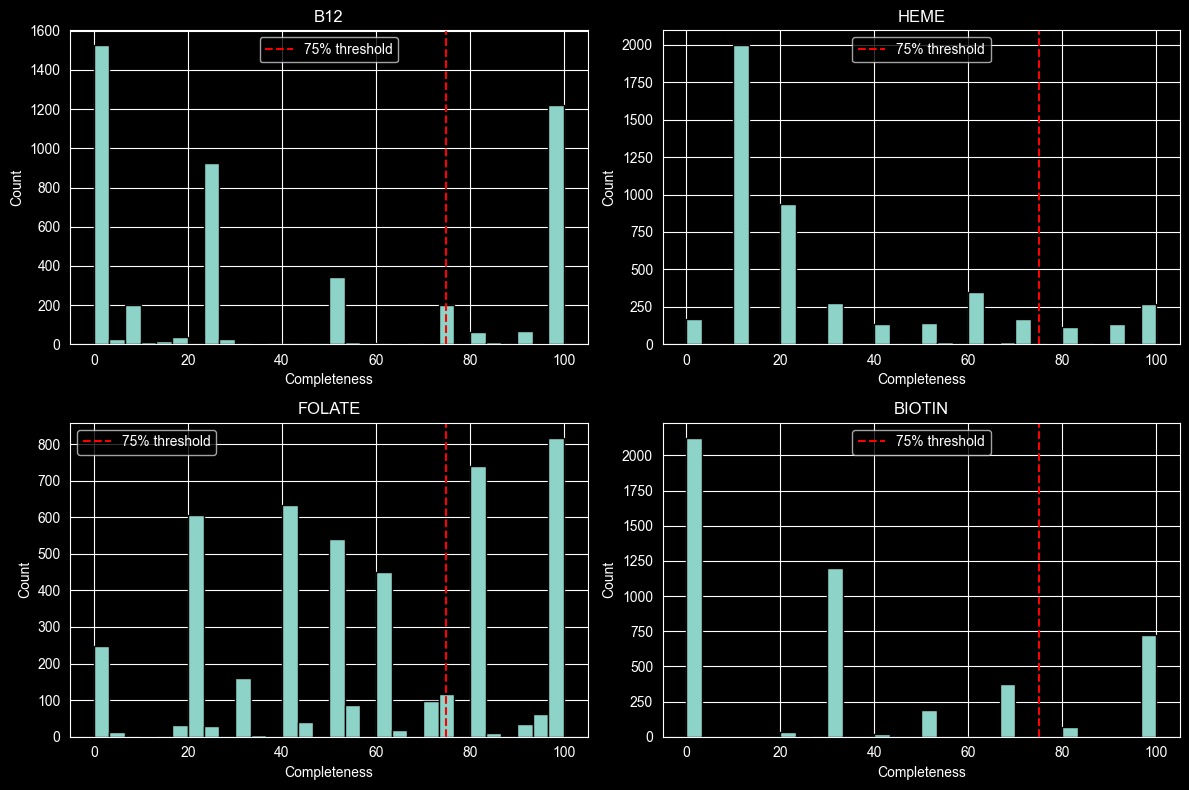

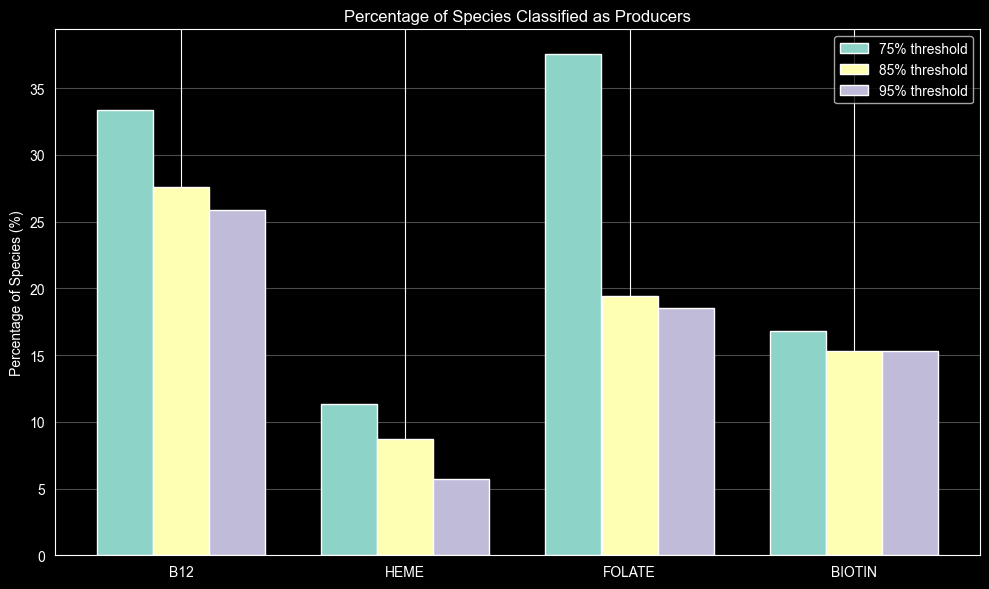


SUMMARY STATISTICS
B12      | Mean:  41.7 | Producers: 1581 ( 33.3%)
HEME     | Mean:  30.4 | Producers:  538 ( 11.3%)
FOLATE   | Mean:  57.4 | Producers: 1780 ( 37.5%)
BIOTIN   | Mean:  32.6 | Producers:  796 ( 16.8%)
TOTAL SPECIES: 4744


In [32]:
traits = list(KEGG_MODULES.keys())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, trait in enumerate(traits):
    ax = axes[idx // 2, idx % 2]
    completeness = completeness_df[f'{trait}_max_completeness']

    ax.hist(completeness, bins=30, edgecolor='black')
    ax.axvline(75, color='red', linestyle='--', label='75% threshold')
    ax.set_title(f'{trait.upper()}')
    ax.set_xlabel('Completeness')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(traits))
width = 0.25

for i, threshold in enumerate([75, 85, 95]):
    percentages = []
    for trait in traits:
        count = completeness_df[f'{trait}_kegg_label_{threshold}'].sum()
        pct = (count / len(completeness_df)) * 100
        percentages.append(pct)

    ax.bar(x + i * width, percentages, width, label=f'{threshold}% threshold')

ax.set_ylabel('Percentage of Species (%)')
ax.set_title('Percentage of Species Classified as Producers')
ax.set_xticks(x + width)
ax.set_xticklabels([t.upper() for t in traits])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSUMMARY STATISTICS")
print("=" * 60)
for trait in traits:
    col = f'{trait}_max_completeness'
    mean_val = completeness_df[col].mean()
    producers = completeness_df[f'{trait}_kegg_label_75'].sum()
    pct = producers / len(completeness_df) * 100

    print(f"{trait.upper():8} | Mean: {mean_val:5.1f} | Producers: {producers:4} ({pct:5.1f}%)")
print("=" * 60)
print(f"TOTAL SPECIES: {len(completeness_df)}")

In [33]:
# Use 75% threshold for final labels
final_labels = completeness_df[['genome_id', 'b12_kegg_label_75',
                                  'heme_kegg_label_75', 'folate_kegg_label_75',
                                  'biotin_kegg_label_75']].copy()
final_labels.columns = ['genome_id', 'b12', 'heme', 'folate', 'biotin']

final_labels.to_csv(FINAL_LABELS, index=False)

In [34]:
"""
1) Get representative Genomes list
2) Write parser for kegg completeness db
3) Filter out to keep Kegg Completeness Scores of relevant Modules only
4) Generate UHGG labels (keep completeness)
5) Validate Labels against Agora (sep notebook)
"""

'\n1) Get representative Genomes list\n2) Write parser for kegg completeness db\n3) Filter out to keep Kegg Completeness Scores of relevant Modules only\n4) Generate UHGG labels (keep completeness)\n5) Validate Labels against Agora (sep notebook)\n'